# Age correlation of individual RSI variability

This notebook calculates a parcel-wise correlation map between age and inter-individual RSI variance in the HCP-D child dataset.


In [ ]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr


project_root = Path('../..').resolve()
info_dir = project_root / 'data' / 'HCPD' / 'info'
results_dir = project_root / 'results' / 'rsi' / 'HCPD'
font_path = project_root / 'font' / 'Whitney-Medium.otf'


from rise import fetch_fine_grained_geodesic_distances

geodist_path = fetch_fine_grained_geodesic_distances()

if font_path.exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'


## Load RSI features and metadata


In [2]:
train_rsi_path = results_dir / 'train_rsi.csv'
test_rsi_path = results_dir / 'test_rsi.csv'

train_rsi = pd.read_csv(train_rsi_path, index_col=0)
test_rsi = pd.read_csv(test_rsi_path, index_col=0)

test_subject_ids = test_rsi.index.tolist()
parcel_names = pd.read_csv(geodist_path, index_col=0, nrows=0).columns.tolist()

hcpd_info_children = pd.read_csv(
    info_dir / 'HCPD_info_children.csv', index_col=0
)
hcpd_info_children['sex'] = [
    1 if value == 'M' else -1
    for value in hcpd_info_children['sex'].values
]

# Normalize the unit scale using the adult mean RSI. This step is optional, as it does not affect parcel-wise analysis results, 
# and is included only to unify the numerical range of RSI values intuitively.
test_rsi = test_rsi / train_rsi.mean()


## Remove sex effects and calculate age-window variance

Sex is regressed out as a confound, then the parcel-wise variance values are correlated with age using Spearman correlation.


In [3]:
# Regress out sex before calculating local inter-subject variance.
from scipy.linalg import lstsq
from sklearn.preprocessing import MinMaxScaler


def residualize_features(feature_table, covariates):
    """Remove covariate effects from each parcel feature."""
    features = feature_table.loc[covariates.index].to_numpy()
    covariance = covariates.to_numpy()
    if features.ndim == 1:
        features = features.reshape(len(features), 1)
    if covariance.ndim == 1:
        covariance = covariance.reshape(len(features), 1)

    design = np.hstack([covariance, np.ones((len(covariance), 1))])
    residuals = np.zeros_like(features)
    residualized = np.zeros_like(features)
    for parcel_index in range(features.shape[1]):
        coefficients = lstsq(design, features[:, parcel_index])[0]
        residuals[:, parcel_index] = (
            features[:, parcel_index]
            - covariance.dot(coefficients[:-1])
        )
        if np.min(features[:, parcel_index]) == np.max(features[:, parcel_index]):
            residualized[:, parcel_index] = features[:, parcel_index]
        else:
            residualized[:, parcel_index] = MinMaxScaler(
                feature_range=(
                    np.min(features[:, parcel_index]),
                    np.max(features[:, parcel_index]),
                )
            ).fit_transform(
                residuals[:, parcel_index].reshape(-1, 1)
            ).ravel()

    return pd.DataFrame(
        residualized,
        index=feature_table.loc[covariates.index].index,
        columns=feature_table.columns,
    )


test_rsi_residual = residualize_features(
    test_rsi,
    hcpd_info_children.loc[test_subject_ids, ['sex']],
)
test_rsi_with_age = pd.DataFrame(
    test_rsi_residual.to_numpy(),
    index=test_subject_ids,
    columns=parcel_names,
).join(hcpd_info_children['age'])

parcel_features = test_rsi_with_age.drop(columns=['age']).to_numpy()
age = test_rsi_with_age['age'].to_numpy()
n_subjects, n_parcels = parcel_features.shape

N_EACH_SIDE = 10
WINDOW_SIZE = 21

if n_subjects < WINDOW_SIZE:
    raise ValueError(f'Number of subjects ({n_subjects}) is smaller than the window size ({WINDOW_SIZE}).')

age_order = np.argsort(age, kind='stable')
variance_by_subject = np.full((n_subjects, n_parcels), np.nan)
valid_mask = np.zeros(n_subjects, dtype=bool)

for center_rank in range(N_EACH_SIDE, n_subjects - N_EACH_SIDE):
    center_index = age_order[center_rank]
    window_indices = age_order[
        center_rank - N_EACH_SIDE:center_rank + N_EACH_SIDE + 1
    ]
    variance_by_subject[center_index] = np.var(
        parcel_features[window_indices], axis=0, ddof=1
    )
    valid_mask[center_index] = True

r_map = np.full(n_parcels, np.nan)
p_map = np.full(n_parcels, np.nan)
for parcel_index in range(n_parcels):
    r_map[parcel_index], p_map[parcel_index] = spearmanr(
        age[valid_mask], variance_by_subject[valid_mask, parcel_index]
    )

print(f'Window size: {WINDOW_SIZE}')
print(f'Valid center subjects: {valid_mask.sum()} / {n_subjects}')
print(f'Positive/negative correlations: +{np.sum(r_map > 0)} / -{np.sum(r_map < 0)}')


Window size: 21
Valid center subjects: 472 / 492
Positive/negative correlations: +2611 / -4729


## Visualize the correlation map


In [4]:
# Find nearest neighbors within each hemisphere and apply Gaussian smoothing.
geodist_matrix_df = pd.read_csv(geodist_path, index_col=0)
geodist_matrix = geodist_matrix_df.values
np.fill_diagonal(geodist_matrix, np.inf)

n_neighbors = 4
n_parcels_per_hemisphere = len(parcel_names) // 2
nearest_neighbors = {}

for parcel_index, row in enumerate(geodist_matrix[:n_parcels_per_hemisphere, :n_parcels_per_hemisphere]):
    neighbor_indices = np.argsort(row)[:n_neighbors]
    nearest_neighbors[parcel_names[parcel_index]] = {
        'neighbor_indices': neighbor_indices,
        'distances': row[neighbor_indices],
    }

for parcel_index, row in enumerate(geodist_matrix[n_parcels_per_hemisphere:, n_parcels_per_hemisphere:]):
    neighbor_indices = np.argsort(row)[:n_neighbors]
    neighbor_indices_global = neighbor_indices + n_parcels_per_hemisphere
    nearest_neighbors[parcel_names[parcel_index + n_parcels_per_hemisphere]] = {
        'neighbor_indices': neighbor_indices_global,
        'distances': row[neighbor_indices],
    }


def smooth_parcel_map(parcel_map, neighbors, parcel_names, method='gaussian', sigma=4):
    """Smooth a parcel map using within-hemisphere nearest neighbors."""
    smoothed_map = np.zeros_like(parcel_map, dtype=np.float32)

    for parcel_index, parcel_name in enumerate(parcel_names):
        neighbor_info = neighbors[parcel_name]
        neighbor_indices = neighbor_info['neighbor_indices']
        neighbor_distances = neighbor_info['distances']
        all_indices = np.append(neighbor_indices, parcel_index)
        all_distances = np.append(neighbor_distances, 0.0)
        all_values = parcel_map[all_indices]

        if method == 'gaussian':
            weights = np.exp(-(all_distances ** 2) / (2 * sigma ** 2))
            smoothed_map[parcel_index] = np.sum(
                all_values * weights / np.sum(weights)
            )
        elif method == 'mean':
            smoothed_map[parcel_index] = np.mean(all_values)
        else:
            raise ValueError("method must be 'gaussian' or 'mean'")

    return smoothed_map


age_variance_correlation_map = smooth_parcel_map(
    parcel_map=r_map,
    neighbors=nearest_neighbors,
    parcel_names=parcel_names,
    method='gaussian',
    sigma=4,
)


In [5]:
from matplotlib.colors import ListedColormap, hsv_to_rgb, rgb_to_hsv


def adjust_colormap_saturation(cmap_name, saturation_factor):
    """Create a colormap with a moderately adjusted saturation."""
    cmap = plt.get_cmap(cmap_name)
    rgba = cmap(np.linspace(0, 1, 256))
    hsv = rgb_to_hsv(rgba[:, :3])
    hsv[:, 1] = np.clip(hsv[:, 1] * saturation_factor, 0, 1)
    rgba[:, :3] = hsv_to_rgb(hsv)
    return ListedColormap(
        rgba,
        name=f'{cmap.name}_sat_{saturation_factor}',
    )


In [6]:
surface_cmap = adjust_colormap_saturation('GnBu', 0.7)


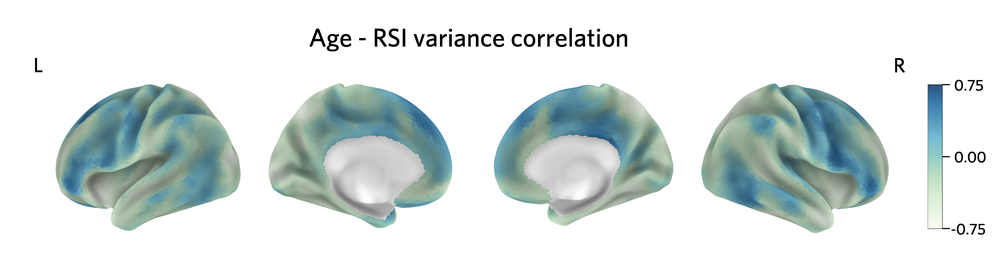

<Figure size 640x480 with 0 Axes>

In [7]:
from IPython.display import display
from rise.surface_plot import visualize_parcel_surface_map


surface_image = visualize_parcel_surface_map(
    age_variance_correlation_map,
    title='Age - RSI variance correlation',
    cmap=surface_cmap,
)
display(surface_image)
